# CLUSTERING LIBÉRE RETO 06- EQUIPO AMARILLO

In [1]:
# Cargar Librerías
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

from sklearn.base import BaseEstimator, ClusterMixin
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score,
    make_scorer
)
from sklearn.model_selection import GridSearchCV

from yellowbrick.cluster import SilhouetteVisualizer, KElbowVisualizer

from sklearn.metrics import pairwise_distances


# Para gráficos en Jupyter
%matplotlib inline

In [2]:
# Cargar datos
path = os.path.join('df_final.csv')
df = pd.read_csv(path)

### 1. Análisis Datos

In [3]:
# Tamaño df
df.shape

(51707, 46)

In [4]:
# Tipo de columnas
print(df.dtypes)

booked_at                          object
checkin_time                       object
lead_time                           int64
lenght_of_stay                      int64
checkin_month                      object
checkin_day                        object
adult_count                         int64
child_count                         int64
origin                             object
travel_agency_name                 object
requested_category                 object
requested_category_name            object
asset                              object
asset_type                         object
brand                              object
available_units                     int64
business_segment                   object
rate                               object
rate_group_name                    object
rate_type                          object
completed_entry_forms_count       float64
all_entry_forms_completed          object
returning_inhabitant               object
recurrence                        

In [5]:
# Visualizar primeras 10 filas
df.head(10)

,booked_at,checkin_time,lead_time,lenght_of_stay,checkin_month,checkin_day,adult_count,child_count,origin,travel_agency_name,...,Estacion_Estancia,Estacion_Reserva,zona_roja_mes,momento_checkin,total_personas_adult_y_niños,ratio_formularios,reservation_checkin_month_diff,estancia_en_festivo,estancia_en_finde,mes_checkin_numerico
0,2022-11-26 16:10:00,2023-01-01 12:00:00,36,1,January,Sunday,1,0,channel_manager,Booking.com,...,Winter,Autumn,0,Antes,1,1.000000,2,0,1,1
1,2022-12-21 17:27:00,2023-01-01 13:09:00,11,9,January,Sunday,1,0,channel_manager,Booking.com,...,Winter,Winter,0,Antes,1,1.000000,1,1,1,1
2,2022-09-21 19:46:00,2023-01-01 15:00:00,102,6,January,Sunday,2,4,channel_manager,Booking.com,...,Winter,Autumn,0,Antes,6,0.333333,4,1,1,1
3,2022-09-24 12:09:00,2023-01-01 15:00:00,99,1,January,Sunday,2,2,channel_manager,Booking.com,...,Winter,Autumn,1,Antes,4,0.500000,4,0,1,1
4,2022-10-18 07:12:00,2023-01-01 15:00:00,75,1,January,Sunday,4,0,channel_manager,Booking.com,...,Winter,Autumn,1,Antes,4,1.000000,3,0,1,1
5,2022-11-25 17:50:00,2023-01-01 15:00:00,37,1,January,Sunday,2,1,channel_manager,Booking.com,...,Winter,Autumn,0,NaN,3,0.000000,2,0,1,1
6,2022-11-26 04:10:00,2023-01-01 15:00:00,36,2,January,Sunday,3,0,channel_manager,Booking.com,...,Winter,Autumn,1,NaN,3,0.000000,2,0,1,1
7,2022-12-02 20:02:00,2023-01-01 15:00:00,30,1,January,Sunday,2,2,channel_manager,Booking.com,...,Winter,Winter,0,Antes,4,0.500000,1,0,1,1
8,2022-12-04 23:18:00,2023-01-01 15:00:00,28,2,January,Sunday,1,0,channel_manager,Booking.com,...,Winter,Winter,0,Durante,1,1.000000,1,0,1,1
9,2022-12-11 12:51:00,2023-01-01 15:00:00,21,7,January,Sunday,2,0,channel_manager,Booking.com,...,Winter,Winter,1,NaN,2,0.000000,1,1,1,1


In [6]:
# Columnas:
df.columns

Index(['booked_at', 'checkin_time', 'lead_time', 'lenght_of_stay',
       'checkin_month', 'checkin_day', 'adult_count', 'child_count', 'origin',
       'travel_agency_name', 'requested_category', 'requested_category_name',
       'asset', 'asset_type', 'brand', 'available_units', 'business_segment',
       'rate', 'rate_group_name', 'rate_type', 'completed_entry_forms_count',
       'all_entry_forms_completed', 'returning_inhabitant', 'recurrence',
       'libere_community', 'bought_products', 'product_count',
       'reservation_net_value', 'total_adr', 'status', 'cancellation_reason',
       'cancellation_lead_time', 'City', 'Reserva_Dia_Semana',
       'Cancelacion_Dia_Semana', 'Estacion_Cancelacion', 'Estacion_Estancia',
       'Estacion_Reserva', 'zona_roja_mes', 'momento_checkin',
       'total_personas_adult_y_niños', 'ratio_formularios',
       'reservation_checkin_month_diff', 'estancia_en_festivo',
       'estancia_en_finde', 'mes_checkin_numerico'],
      dtype='object')

### 2. Selección Variables (Numericas, Booleanas, Categóricas)
##### 1. **Variables Cancelacion**: Principalmente se deben excluir aquellas variables que le daran infromacion al modelo que ese cliente vaya a cancelar (Checkin_time, ratio_cancelaciones....).<br>**2. Variables Ctaegoricas** : Convertir a variables dummies <br>3. **Variables Numericas:** Escalar los valores, con min max (Estandar escaler no!)

In [7]:
# funcion para detectar columnas y que si son del tipo yes/no las convierta en 0/1 e identifique como booleanas
def detectar_tipos_columnas(df: pd.DataFrame):
    """
    Detecta columnas numéricas, booleanas (incluyendo 0/1 y yes/no) y categóricas en un DataFrame.
    Convierte automáticamente las columnas de tipo 'yes/no' o 'True/False' en 0/1.
    
    Parámetros
    ----------
    df : pd.DataFrame
        El DataFrame a analizar.

    Retorna
    -------
    dict
        Un diccionario con tres claves:
        - 'numericas': lista de columnas numéricas (excluyendo las booleanas)
        - 'booleanas': lista de columnas booleanas (bool, {0,1} o 'yes'/'no', 'True'/'False')
        - 'categoricas': lista de columnas categóricas (object o category)
    """
    
    # Copiamos el DataFrame para no modificar el original
    df = df.copy()
    
    # creamos las listas de los nombres de las columnas
    columnas_booleanas = []
    columnas_numericas = []
    columnas_categoricas = []

    # recorremos cada columna
    for col in df.columns:
        serie = df[col]
        dtype = serie.dtype

        # Si es booleana, que lo almacene en la lista de las columnas booleanas
        if pd.api.types.is_bool_dtype(dtype):
            columnas_booleanas.append(col)
            continue

        # Si la columna es numerica y si los valores unicos son 0, 1 que lo almacene en columnas booleanas, sino en columnas numericas
        if pd.api.types.is_numeric_dtype(dtype):
            valores_unicos = serie.dropna().unique()
            if set(valores_unicos).issubset({0, 1}):
                columnas_booleanas.append(col)
            else:
                columnas_numericas.append(col)
            continue

        # Si la columna es Yes/no o True/False que lo cambie por 1/0 y lo almacene en booleana, sino en categorica
        if pd.api.types.is_object_dtype(dtype) or pd.api.types.is_categorical_dtype(dtype):
            # Normalizamos a minúsculas
            valores_unicos = serie.dropna().astype(str).str.lower().unique()
            yes_no_set = {'yes', 'no', 'si', 'sí', 'true', 'false', 'True', 'False','y', 'n'}

            if set(valores_unicos).issubset(yes_no_set):
                # Convertimos a 1/0
                df[col] = serie.astype(str).str.lower().map({
                    'yes': 1, 'si': 1, 'sí': 1, 'true': 1, 'y': 1,
                    'no': 0, 'false': 0, 'n': 0, 'True':1, 'False':0
                })
                columnas_booleanas.append(col)
            else:
                columnas_categoricas.append(col)
            continue

    return {
        'numericas': columnas_numericas,
        'booleanas': columnas_booleanas,
        'categoricas': columnas_categoricas,
        'dataframe_transformado': df
    }
resultado = detectar_tipos_columnas(df)
print(resultado)
df_transformado = resultado['dataframe_transformado']


{'numericas': ['lead_time', 'lenght_of_stay', 'adult_count', 'child_count', 'available_units', 'completed_entry_forms_count', 'recurrence', 'product_count', 'reservation_net_value', 'total_adr', 'cancellation_lead_time', 'total_personas_adult_y_niños', 'ratio_formularios', 'reservation_checkin_month_diff', 'mes_checkin_numerico'], 'booleanas': ['all_entry_forms_completed', 'returning_inhabitant', 'libere_community', 'bought_products', 'zona_roja_mes', 'estancia_en_festivo', 'estancia_en_finde'], 'categoricas': ['booked_at', 'checkin_time', 'checkin_month', 'checkin_day', 'origin', 'travel_agency_name', 'requested_category', 'requested_category_name', 'asset', 'asset_type', 'brand', 'business_segment', 'rate', 'rate_group_name', 'rate_type', 'status', 'cancellation_reason', 'City', 'Reserva_Dia_Semana', 'Cancelacion_Dia_Semana', 'Estacion_Cancelacion', 'Estacion_Estancia', 'Estacion_Reserva', 'momento_checkin'], 'dataframe_transformado':                  booked_at         checkin_time  

In [8]:
#Crear data frame final con las columnas que no tienen relacion con la cancelacion:
cols_clustering = [
    'lead_time','lenght_of_stay','checkin_month','checkin_day','adult_count','child_count',
    'origin','requested_category','asset','asset_type','business_segment','rate_type',
    'returning_inhabitant','recurrence','libere_community','reservation_net_value',
    'zona_roja_mes','Estacion_Estancia',
    'Estacion_Reserva','estancia_en_festivo','estancia_en_finde','City', 'mes_checkin_numerico',
    'reservation_checkin_month_diff', 'Reserva_Dia_Semana'
]

df_clustering = df_transformado[cols_clustering]
print(df_clustering)

       lead_time  lenght_of_stay checkin_month checkin_day  adult_count  \
0             36               1       January      Sunday            1   
1             11               9       January      Sunday            1   
2            102               6       January      Sunday            2   
3             99               1       January      Sunday            2   
4             75               1       January      Sunday            4   
...          ...             ...           ...         ...          ...   
51702         79               1      December      Sunday            4   
51703         79               1      December      Sunday            4   
51704         75               1      December      Sunday            5   
51705         75               1      December      Sunday            4   
51706          1               2      December      Sunday            2   

       child_count           origin              requested_category  \
0                0  channel_

### 3. Escalar Variables Numericas

In [9]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

def escalar_numericas(df, columnas_numericas=None):
    """
    Escala únicamente las columnas numéricas de un DataFrame usando MinMaxScaler.
    
    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame original.
    columnas_numericas : list (opcional)
        Lista de columnas numéricas. Si no se pasa, se detectan automáticamente.
    
    Retorna
    -------
    pd.DataFrame
        DataFrame con columnas numéricas escaladas entre 0 y 1.
    """

    df_copy = df.copy()

    # Detectar columnas numéricas si no se pasan
    if columnas_numericas is None:
        columnas_numericas = df_copy.select_dtypes(include=['int64', 'float64']).columns.tolist()

    scaler = MinMaxScaler()

    # Escalar solo las numéricas
    df_copy[columnas_numericas] = scaler.fit_transform(df_copy[columnas_numericas])

    return df_copy

df_clustering_scaled = escalar_numericas(df_clustering)
df_clustering_scaled

,lead_time,lenght_of_stay,checkin_month,checkin_day,adult_count,child_count,origin,requested_category,asset,asset_type,...,reservation_net_value,zona_roja_mes,Estacion_Estancia,Estacion_Reserva,estancia_en_festivo,estancia_en_finde,City,mes_checkin_numerico,reservation_checkin_month_diff,Reserva_Dia_Semana
0,0.047461,0.012658,January,Sunday,0.1,0.00,channel_manager,Hostel bed,Koisi Hostel,hostel,...,0.015921,0.0,Winter,Autumn,0.0,1.0,Donostia,0.0,0.100000,Saturday
1,0.019868,0.113924,January,Sunday,0.1,0.00,channel_manager,Hostel bed,Koisi Hostel,hostel,...,0.117788,0.0,Winter,Winter,1.0,1.0,Donostia,0.0,0.066667,Wednesday
2,0.120309,0.075949,January,Sunday,0.2,0.50,channel_manager,Hostel room,Koisi Hostel,hostel,...,0.755703,0.0,Winter,Autumn,1.0,1.0,Donostia,0.0,0.166667,Wednesday
3,0.116998,0.012658,January,Sunday,0.2,0.25,channel_manager,Hostel room,Koisi Hostel,hostel,...,0.186383,1.0,Winter,Autumn,0.0,1.0,Donostia,0.0,0.166667,Saturday
4,0.090508,0.012658,January,Sunday,0.4,0.00,channel_manager,Hostel room,Koisi Hostel,hostel,...,0.077025,1.0,Winter,Autumn,0.0,1.0,Donostia,0.0,0.133333,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51702,0.094923,0.012658,December,Sunday,0.4,0.00,telephone,One bedroom apartment,Líbere Pamplona Yamaguchi,apartment,...,0.169612,0.0,Winter,Autumn,0.0,1.0,Pamplona,1.0,0.100000,Friday
51703,0.094923,0.012658,December,Sunday,0.4,0.00,telephone,One bedroom apartment,Líbere Pamplona Yamaguchi,apartment,...,0.169612,0.0,Winter,Autumn,0.0,1.0,Pamplona,1.0,0.100000,Friday
51704,0.090508,0.012658,December,Sunday,0.5,0.00,direct_channel,Two bedroom apartment,Líbere Pamplona Yamaguchi,apartment,...,0.647325,0.0,Winter,Autumn,0.0,1.0,Pamplona,1.0,0.100000,Tuesday
51705,0.090508,0.012658,December,Sunday,0.4,0.00,direct_channel,Two bedroom apartment superior,Líbere Pamplona Yamaguchi,apartment,...,0.732781,0.0,Winter,Autumn,0.0,1.0,Pamplona,1.0,0.100000,Tuesday


### 4. Conversión de Categóricas a dummies

In [10]:
import pandas as pd

def convertir_a_dummies(df, columnas_categoricas=None, drop_first=True):
    """
    Convierte columnas categóricas en variables dummies (one-hot encoding).

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame original.
    columnas_categoricas : list (opcional)
        Lista de columnas categóricas. Si no se pasa, se detectan automáticamente.
    drop_first : bool
        Si True, elimina la primera categoría (evita colinealidad).

    Retorna
    -------
    pd.DataFrame
        DataFrame con las columnas categóricas convertidas en dummies.
    """

    df_copy = df.copy()

    # Detectar categóricas si no se pasan
    if columnas_categoricas is None:
        columnas_categoricas = df_copy.select_dtypes(include=['object', 'category']).columns.tolist()

    df_dummies = pd.get_dummies(df_copy, columns=columnas_categoricas, drop_first=drop_first)

    return df_dummies


df_clustering_final = convertir_a_dummies(df_clustering_scaled)
df_clustering_final

,lead_time,lenght_of_stay,adult_count,child_count,returning_inhabitant,recurrence,libere_community,reservation_net_value,zona_roja_mes,estancia_en_festivo,...,City_Málaga,City_Pamplona,City_Valencia,City_Vitoria,Reserva_Dia_Semana_Monday,Reserva_Dia_Semana_Saturday,Reserva_Dia_Semana_Sunday,Reserva_Dia_Semana_Thursday,Reserva_Dia_Semana_Tuesday,Reserva_Dia_Semana_Wednesday
0,0.047461,0.012658,0.1,0.00,1.0,0.026087,0.0,0.015921,0.0,0.0,...,False,False,False,False,False,True,False,False,False,False
1,0.019868,0.113924,0.1,0.00,1.0,0.008696,1.0,0.117788,0.0,1.0,...,False,False,False,False,False,False,False,False,False,True
2,0.120309,0.075949,0.2,0.50,0.0,0.000000,0.0,0.755703,0.0,1.0,...,False,False,False,False,False,False,False,False,False,True
3,0.116998,0.012658,0.2,0.25,0.0,0.000000,0.0,0.186383,1.0,0.0,...,False,False,False,False,False,True,False,False,False,False
4,0.090508,0.012658,0.4,0.00,0.0,0.000000,0.0,0.077025,1.0,0.0,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51702,0.094923,0.012658,0.4,0.00,0.0,0.000000,1.0,0.169612,0.0,0.0,...,False,True,False,False,False,False,False,False,False,False
51703,0.094923,0.012658,0.4,0.00,0.0,0.000000,1.0,0.169612,0.0,0.0,...,False,True,False,False,False,False,False,False,False,False
51704,0.090508,0.012658,0.5,0.00,0.0,0.000000,1.0,0.647325,0.0,0.0,...,False,True,False,False,False,False,False,False,True,False
51705,0.090508,0.012658,0.4,0.00,0.0,0.000000,1.0,0.732781,0.0,0.0,...,False,True,False,False,False,False,False,False,True,False


# PCA (Solo para visualizacion)

- PCA requiere variables numéricas
- Distancias euclídeas → escalar antes 
- Usamos StandardScaler SOLO para PCA, no para clustering final

In [11]:
scaler_pca = StandardScaler()
X_pca = scaler_pca.fit_transform(df_clustering_final)

pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(X_pca)


### 5. Creación Función: Evaluación INTERNA

In [12]:
def evaluar_clustering(X, labels):
    if len(np.unique(labels)) < 2:
        return np.nan, np.nan, np.nan

    sil = silhouette_score(X, labels)
    db  = davies_bouldin_score(X, labels)
    ch  = calinski_harabasz_score(X, labels)

    return sil, db, ch

# 6. MODELOS (K-Means, Jerarquico, BDSCAN)

## MODELOS (K-Means, Jerarquico, BDSCAN)

#### Visualizacíon Metodo del Codo

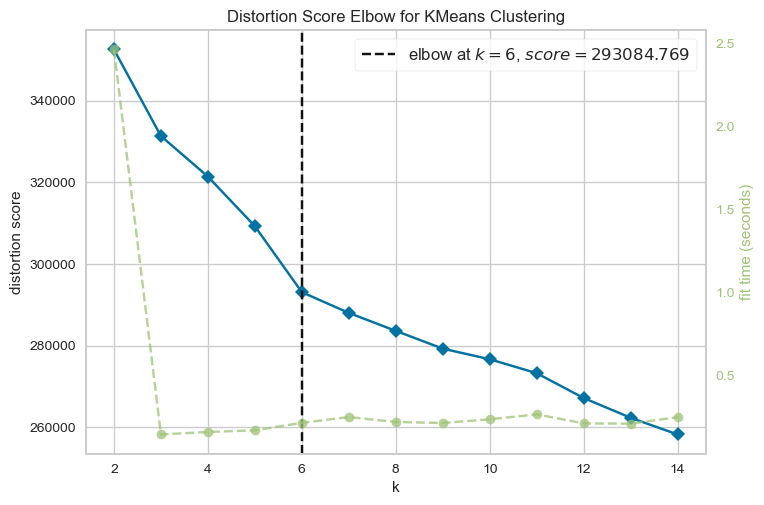

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [13]:
# Modelo base de KMeans (sin especificar k todavía)
model = KMeans(random_state=42)

# Rango de k a evaluar (incluye valores del 2 al 10)
k = (2, 15)

# Crear el visualizador del método del codo
visualizer = KElbowVisualizer(
    model, 
    k=k, 
    timings=True    #muestra tiempo de entrenamiento
)

# Ajustar el visualizador a los datos
visualizer.fit(df_clustering_final)

# Mostrar la gráfica final
visualizer.show()


## 1º Modelo: K-means

In [14]:
#------------------------------------    Busqueda de k
# Probamos distintos k (2 a 10)
k_values = range(2, 15)
inertias = []
silhouettes = []

for k in k_values:
    modelo = KMeans(n_clusters=k, n_init=10, random_state=42)
    etiquetas = modelo.fit_predict(df_clustering_final)
    inertias.append(modelo.inertia_)
    silhouettes.append(silhouette_score(df_clustering_final, etiquetas))

print(inertias)
print(silhouettes)

[352570.8182402428, 325199.88370142883, 307918.9107345029, 299520.44432299037, 292048.2636352843, 285862.36747895816, 280825.3331828104, 277360.3228557641, 272141.57880135276, 267266.0005308343, 263509.33578754193, 260589.34240097489, 255121.3801141682]
[np.float64(0.09970523232174137), np.float64(0.12728040088843584), np.float64(0.11294306659293489), np.float64(0.11120940163406696), np.float64(0.1137555875960233), np.float64(0.0993748687614202), np.float64(0.100253158149856), np.float64(0.0921530363738216), np.float64(0.08513947649065694), np.float64(0.09838034018888567), np.float64(0.08802262207139012), np.float64(0.09371762212732426), np.float64(0.09543941328652454)]


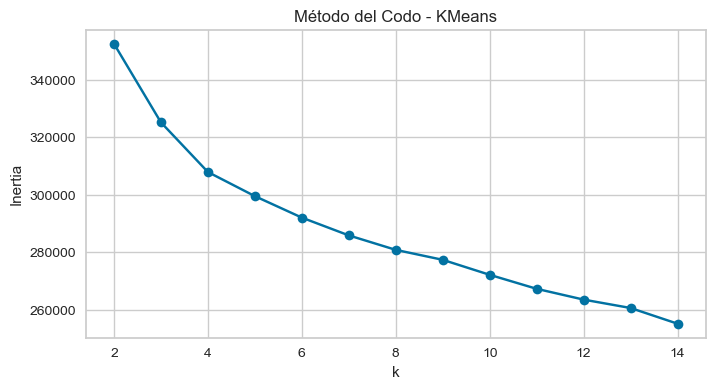

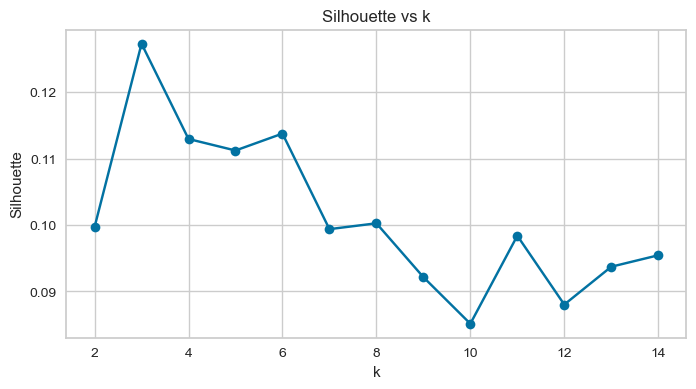

In [15]:
#------------------------------------    Graficos

# Método del codo
plt.figure(figsize=(8,4))
plt.plot(k_values, inertias, '-o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Método del Codo - KMeans")
plt.show()

# Índice de Silueta
plt.figure(figsize=(8,4))
plt.plot(k_values, silhouettes, '-o')
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.title("Silhouette vs k")
plt.show()

### 1.1º Aplicar K-Means para cada valor de K.
Ademas se visualizaran la distribucion de registros por cluster + Metricas de validacion Interna

In [16]:
# Función para evaluar clustering
def evaluar_clustering(X, labels):
    if len(np.unique(labels)) < 2:
        return np.nan, np.nan, np.nan

    sil = silhouette_score(X, labels)
    db  = davies_bouldin_score(X, labels)
    ch  = calinski_harabasz_score(X, labels)

    return sil, db, ch

# Valores de k a probar
k_values_prueba = [3, 4, 5]
X = df_clustering_final.values

resultados_clusters = {}

for k in k_values_prueba:

    print(f"\n--- k = {k} ---")

    # Ajustar KMeans
    modelo = KMeans(n_clusters=k, n_init=10, random_state=42)
    etiquetas = modelo.fit_predict(X)

    # SANITY CHECK
    print("Clusters únicos:", np.unique(etiquetas))

    # Centroides
    centroides = pd.DataFrame(
        modelo.cluster_centers_,
        columns=df_clustering_final.columns
    )
    centroides["cluster"] = range(k)

    # Instancias por cluster
    instancias_por_cluster = np.bincount(etiquetas)

    # Evaluar clustering
    sil, db, ch = evaluar_clustering(X, etiquetas)

    # Guardar resultados
    resultados_clusters[k] = {
        "modelo": modelo,
        "etiquetas": etiquetas,
        "centroides": centroides,
        "instancias_por_cluster": instancias_por_cluster,
        "silhouette": sil,
        "davies_bouldin": db,
        "calinski_harabasz": ch
    }

    # Imprimir resultados
    print("Instancias por cluster:", instancias_por_cluster)
    
    # Tabla de métricas
    tabla_metricas = pd.DataFrame({
        "Métrica": ["Silhouette", "Davies-Bouldin", "Calinski-Harabasz"],
        "Valor": [sil, db, ch]
    })
    
    print("\nMétricas de validación interna:")
    print(tabla_metricas)



--- k = 3 ---
Clusters únicos: [0 1 2]
Instancias por cluster: [20060 19287 12360]

Métricas de validación interna:
             Métrica        Valor
0         Silhouette     0.127280
1     Davies-Bouldin     2.623028
2  Calinski-Harabasz  5436.867216

--- k = 4 ---
Clusters únicos: [0 1 2 3]
Instancias por cluster: [19287 10103  9957 12360]

Métricas de validación interna:
             Métrica        Valor
0         Silhouette     0.112943
1     Davies-Bouldin     2.549303
2  Calinski-Harabasz  4795.144405

--- k = 5 ---
Clusters únicos: [0 1 2 3 4]
Instancias por cluster: [ 9957 12360  5175 10103 14112]

Métricas de validación interna:
             Métrica        Valor
0         Silhouette     0.111209
1     Davies-Bouldin     2.850999
2  Calinski-Harabasz  4059.556400


### 1.2º Distancias Intra-Cluster e Inter-Cluster + Centroides

In [17]:
# Convertir todo a float
X_numeric = df_clustering_final.values.astype(float)

# Función para calcular la distancia intra-cluster promedio global
def calcular_intra_cluster(X, labels):
    intra_distancias = []
    for cluster in set(labels):
        if cluster == -1:  # ignorar ruido
            continue
        miembros = X[labels == cluster]
        if len(miembros) > 1:
            dist = pairwise_distances(miembros)
            intra_distancias.append(np.mean(dist))
    return np.mean(intra_distancias) if intra_distancias else np.nan

In [18]:
# Función para calcular la distancia mínima inter-cluster
def calcular_inter_cluster(X, labels):
    centroides = []
    for cluster in set(labels):
        if cluster == -1:
            continue
        centroides.append(X[labels == cluster].mean(axis=0))
    
    if len(centroides) < 2:
        return np.nan

    dist_centroides = pairwise_distances(centroides)
    np.fill_diagonal(dist_centroides, np.nan)  # ignorar diagonal
    return np.nanmin(dist_centroides)


In [19]:
# Función para obtener centroides por cluster
def obtener_centroides(X, labels):
    centroides = []
    for cluster in set(labels):
        if cluster == -1:
            continue
        centroides.append(X[labels == cluster].mean(axis=0))
    return np.array(centroides)

In [20]:
# Lista de valores de k
k_values = [3, 4, 5]

for k in k_values:
    resultado = resultados_clusters[k]
    etiquetas = resultado["etiquetas"]

    print(f"\n--- k = {k} ---")

    # Distancia intra-cluster promedio global
    dist_intra_promedio = calcular_intra_cluster(X_numeric, etiquetas)

    # Distancia mínima inter-cluster
    dist_inter = calcular_inter_cluster(X_numeric, etiquetas)

    # Centroides
    centroides = obtener_centroides(X_numeric, etiquetas)

    # Tabla resumen de distancias
    tabla_distancias = pd.DataFrame({
        "Distancia_intra_promedio": [round(dist_intra_promedio, 4)],
        "Distancia_min_inter (Minima)": [round(dist_inter, 4)]
    })

    # Tabla de centroides
    tabla_centroides = pd.DataFrame(centroides, columns=df_clustering_final.columns)

    # Imprimir resultados
    print("\nDistancias INTRA e INTER globales:")
    print(tabla_distancias)
    print("\CENTROIDES por cluster (resumen primeras 2 columnas y 2 filas):")
    print(tabla_centroides.iloc[:2, :2])
    print("--------------------------------------------------------------------------------------------------------------------------------------")


--- k = 3 ---

Distancias INTRA e INTER globales:
   Distancia_intra_promedio  Distancia_min_inter (Minima)
0                     3.492                        1.9062
\CENTROIDES por cluster (resumen primeras 2 columnas y 2 filas):
   lead_time  lenght_of_stay
0   0.042347        0.024421
1   0.037864        0.030085
--------------------------------------------------------------------------------------------------------------------------------------

--- k = 4 ---

Distancias INTRA e INTER globales:
   Distancia_intra_promedio  Distancia_min_inter (Minima)
0                      3.33                        1.8564
\CENTROIDES por cluster (resumen primeras 2 columnas y 2 filas):
   lead_time  lenght_of_stay
0   0.037864        0.030085
1   0.053220        0.024477
--------------------------------------------------------------------------------------------------------------------------------------

--- k = 5 ---

Distancias INTRA e INTER globales:
   Distancia_intra_promedio  Distancia_mi

### 1.3º Visualizar Silhoutte para cada valor de K (3,4,5):


=== Silhouette analysis para k = 3 ===
Silhouette promedio: 0.1273


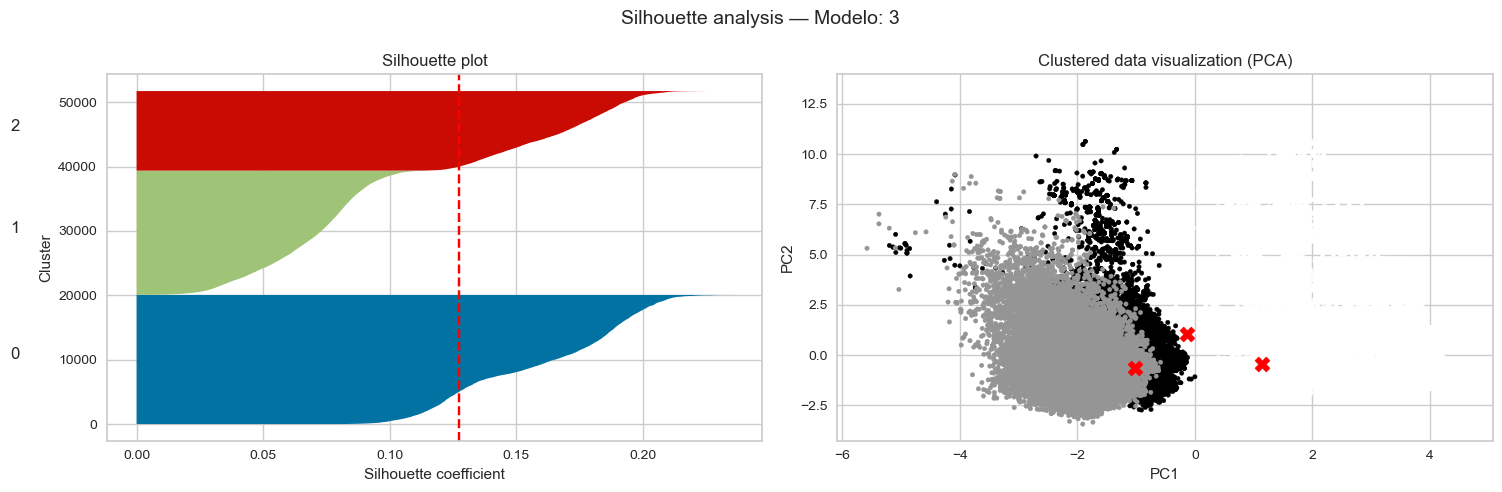


=== Silhouette analysis para k = 4 ===
Silhouette promedio: 0.1129


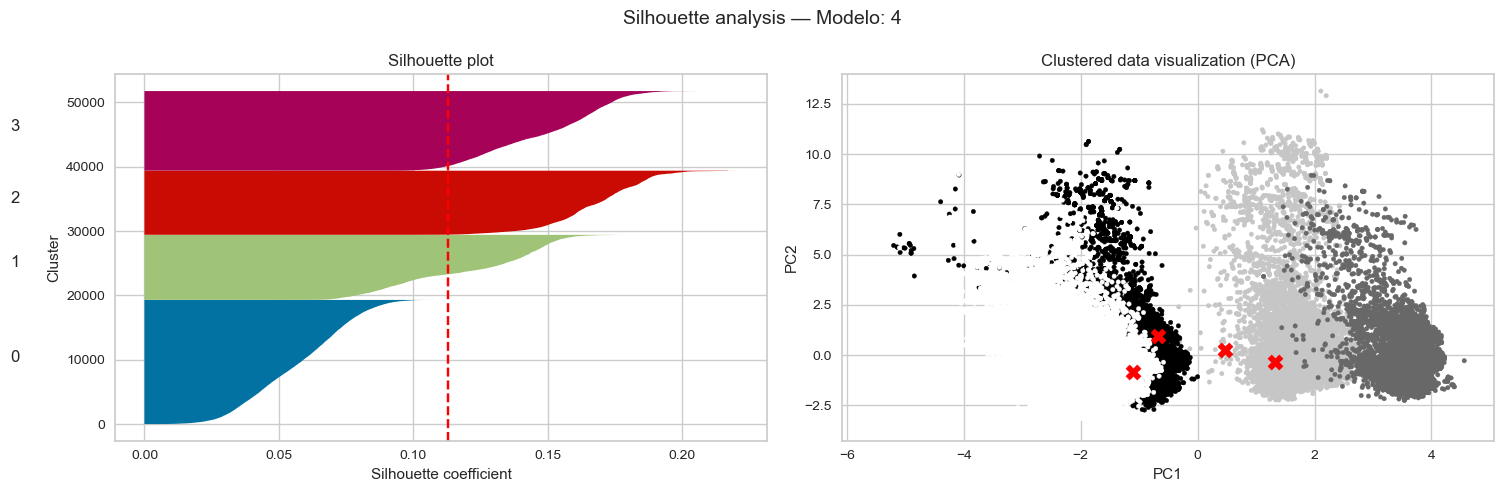


=== Silhouette analysis para k = 5 ===
Silhouette promedio: 0.1112


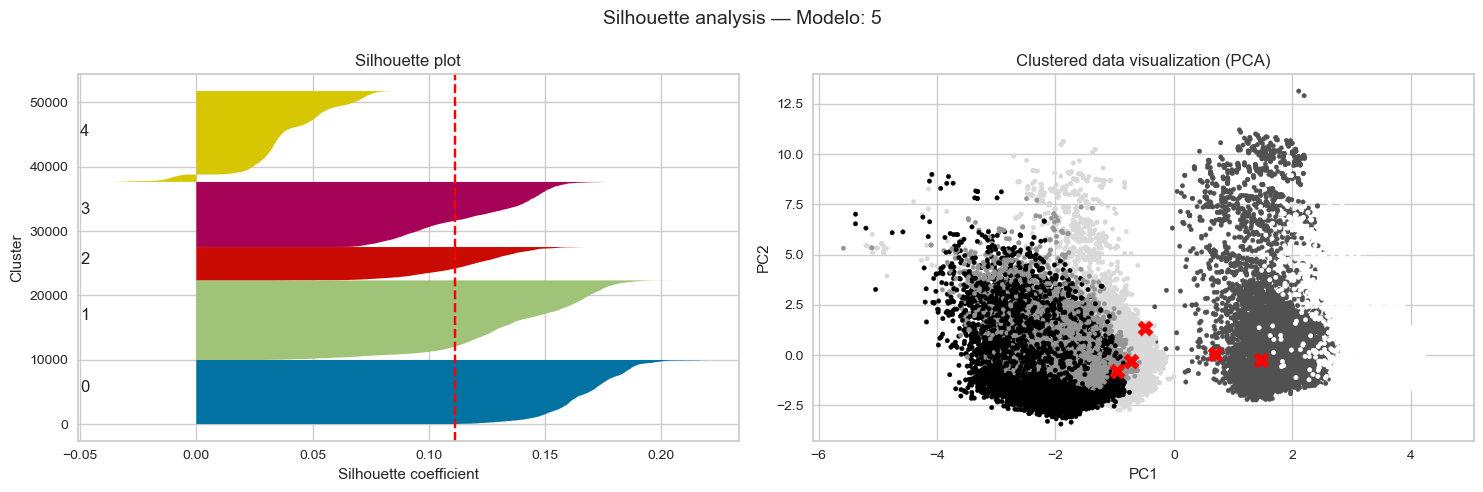

In [21]:
# VISUALIZAR SILHOUTTE PARA CADA K:
k_values_prueba = [3, 4, 5]

for k in k_values_prueba:

    print(f"\n=== Silhouette analysis para k = {k} ===")

    # Entrenar KMeans
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(df_clustering_final)

    # Métricas Silhouette
    silhouette_avg = silhouette_score(df_clustering_final, labels)
    sample_silhouette_values = silhouette_samples(df_clustering_final, labels)

    print(f"Silhouette promedio: {silhouette_avg:.4f}")

    # Crear figura
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f"Silhouette analysis — Modelo: {k}", fontsize=14)

    # ===== SILHOUETTE PLOT =====
    y_lower = 10
    for i in range(k):
        ith_cluster_values = sample_silhouette_values[labels == i]
        ith_cluster_values.sort()

        size_cluster = ith_cluster_values.shape[0]
        y_upper = y_lower + size_cluster

        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_values
        )

        ax1.text(-0.05, y_lower + size_cluster / 2, str(i))
        y_lower = y_upper + 10

    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_xlabel("Silhouette coefficient")
    ax1.set_ylabel("Cluster")
    ax1.set_title("Silhouette plot")

    # ===== SCATTER (PCA) =====
    ax2.scatter(
        X_pca_2d[:, 0],
        X_pca_2d[:, 1],
        c=labels,
        s=10
    )

    centers_pca = PCA(n_components=2).fit_transform(kmeans.cluster_centers_)
    ax2.scatter(
        centers_pca[:, 0],
        centers_pca[:, 1],
        c="red",
        s=120,
        marker="X"
    )

    ax2.set_title("Clustered data visualization (PCA)")
    ax2.set_xlabel("PC1")
    ax2.set_ylabel("PC2")

    plt.tight_layout()
    plt.show()


### 1.4º RESÚMEN Final Metricas + Distancias --> KMEANS

In [22]:
# Crear tabla final con todas las métricas y distancias usando resultados_clusters
filas = []

for k, res in resultados_clusters.items():
    etiquetas = res['etiquetas']
    
    # Distancia intra-cluster promedio global
    dist_intra = calcular_intra_cluster(X_numeric, etiquetas)
    
    # Distancia mínima inter-cluster
    dist_inter = calcular_inter_cluster(X_numeric, etiquetas)
    
    filas.append({
        'k': k,
        'Silhouette': res['silhouette'],
        'Davies-Bouldin': res['davies_bouldin'],
        'Calinski-Harabasz': res['calinski_harabasz'],
        'Distancia_intra_promedio': round(dist_intra, 4),
        'Distancia_min_inter': round(dist_inter, 4)
    })

# Convertir a DataFrame y redondear a 4 decimales
tabla_comparativa = pd.DataFrame(filas).sort_values('k').reset_index(drop=True)

print("\n=== Comparación de métricas y distancias por k ===")
display(tabla_comparativa)
print(tabla_comparativa)



=== Comparación de métricas y distancias por k ===


,k,Silhouette,Davies-Bouldin,Calinski-Harabasz,Distancia_intra_promedio,Distancia_min_inter
0,3,0.127280,2.623028,5436.867216,3.4920,1.9062
1,4,0.112943,2.549303,4795.144405,3.3300,1.8564
2,5,0.111209,2.850999,4059.556400,3.3413,1.4893


   k  Silhouette  Davies-Bouldin  Calinski-Harabasz  Distancia_intra_promedio  \
0  3    0.127280        2.623028        5436.867216                    3.4920   
1  4    0.112943        2.549303        4795.144405                    3.3300   
2  5    0.111209        2.850999        4059.556400                    3.3413   

   Distancia_min_inter  
0               1.9062  
1               1.8564  
2               1.4893  


### Elegir mejor valor de K:
Según la Silhouette y distancias

In [23]:
# Seleccionar k con mayor Silhouette
k_mejor = int(tabla_comparativa.loc[tabla_comparativa['Silhouette'].idxmax(), 'k'])
print(f"Mejor k según Silhouette: {k_mejor}")

# Mostrar resumen 2x2 de centroides
centroides_final = resultados_clusters[k_mejor]['centroides']
print("\nCentroides del modelo final (resumen 2x2):")
display(centroides_final.iloc[:2, :2].round(4))



Mejor k según Silhouette: 3

Centroides del modelo final (resumen 2x2):


,lead_time,lenght_of_stay
0,0.0423,0.0244
1,0.0379,0.0301


### --> MODELO JERARQUICO SELECCINADO : k=?

In [24]:
# Extraer fila del mejor k
tabla_mejor_k_KMEANS = tabla_comparativa[tabla_comparativa['k'] == k_mejor].reset_index(drop=True)

print(f"\n=== Métricas y distancias del mejor k seleccionado (k = {k_mejor}) ===")
display(tabla_mejor_k_KMEANS)



=== Métricas y distancias del mejor k seleccionado (k = 3) ===


,k,Silhouette,Davies-Bouldin,Calinski-Harabasz,Distancia_intra_promedio,Distancia_min_inter
0,3,0.12728,2.623028,5436.867216,3.492,1.9062


# -------------------------------------------------------------------------------------------

## 2º Modelo: Jerarquico

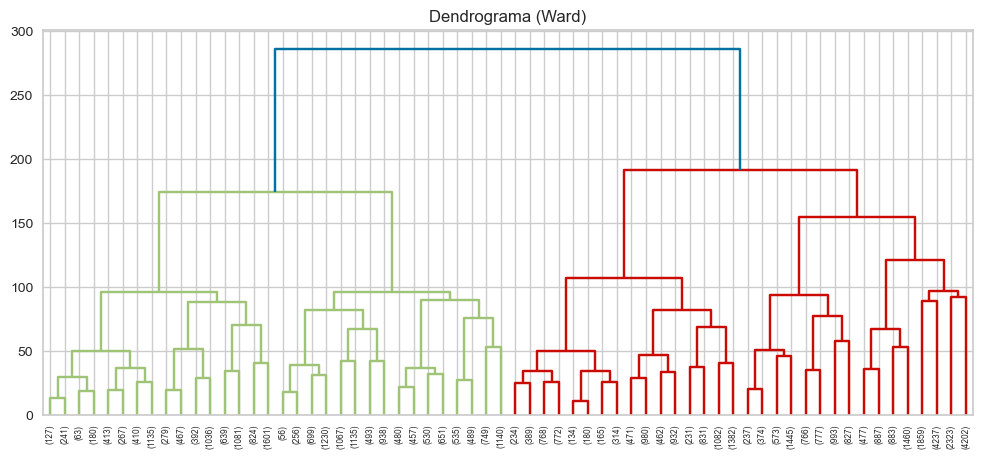

In [25]:
#------------------------------------    Dendrograma
Z = linkage(df_clustering_final, method='ward')
plt.figure(figsize=(12,5))
dendrogram(Z, truncate_mode='level', p=5)
plt.title("Dendrograma (Ward)")
plt.show()


### 2.1º Crear Modelo (k=3,4,5)

In [26]:
#------------------------------------    Modelo Final

# Clustering final con k igual al del método del codo
# Para 3 clusters
k_hier = 3
agglo = AgglomerativeClustering(n_clusters=k_hier, linkage='ward')
labels_agglo = agglo.fit_predict(df_clustering_final)

# Para 4 clusters
k_hier = 4
agglo = AgglomerativeClustering(n_clusters=k_hier, linkage='ward')
labels_agglo = agglo.fit_predict(df_clustering_final)

# Para 5 clusters
k_hier = 5
agglo = AgglomerativeClustering(n_clusters=k_hier, linkage='ward')
labels_agglo = agglo.fit_predict(df_clustering_final)



### 2.2º Metricas de Validación Interna:

In [27]:
#“Debido al alto número de observaciones y variables, el clustering jerárquico con linkage Ward resulta computacionalmente costoso. 
# Por ello, se aplica previamente una reducción de dimensionalidad mediante PCA, manteniendo la mayor parte de la varianza explicada, 
# y se realiza el clustering sobre este espacio reducido.”

### 2.3º Distancias Intra-Cluster e Inter-Cluster + Centroides

In [28]:
# Evaluar para k=3 y k=4
for k_hier in [3, 4, 5]:
    agglo = AgglomerativeClustering(n_clusters=k_hier, linkage='ward')
    labels_agglo = agglo.fit_predict(df_clustering_final)

    print(f"\n=== Resultados Jerárquicos para k={k_hier} ===")
    
    # Clusters únicos e instancias
    print("Clusters únicos:", np.unique(labels_agglo))
    print("Instancias por cluster:", np.bincount(labels_agglo))
    
    # Métricas internas
    sil, db, ch = evaluar_clustering(df_clustering_final.values, labels_agglo)
    tabla_metricas = pd.DataFrame({
        "Métrica": ["Silhouette", "Davies-Bouldin", "Calinski-Harabasz"],
        "Valor": [round(sil, 4), round(db, 4), round(ch, 4)]
    })
    print("\nMétricas de validación interna:")
    display(tabla_metricas)
    
    # Distancias intra e inter
    intra = calcular_intra_cluster(df_clustering_final.values, labels_agglo)
    inter = calcular_inter_cluster(df_clustering_final.values, labels_agglo)
    
    tabla_distancias = pd.DataFrame({
        "Tipo de distancia": ["Intra-cluster", "Inter-cluster"],
        "Valor promedio": [round(intra, 4), round(inter, 4)]
    })
    print("\nDistancias promedio:")
    display(tabla_distancias)


=== Resultados Jerárquicos para k=3 ===
Clusters únicos: [0 1 2]
Instancias por cluster: [20060 22320  9327]

Métricas de validación interna:


,Métrica,Valor
0,Silhouette,0.1018
1,Davies-Bouldin,2.9237
2,Calinski-Harabasz,4587.4789



Distancias promedio:


,Tipo de distancia,Valor promedio
0,Intra-cluster,3.4988
1,Inter-cluster,1.6678



=== Resultados Jerárquicos para k=4 ===
Clusters únicos: [0 1 2 3]
Instancias por cluster: [22320 10905  9327  9155]

Métricas de validación interna:


...

,Tipo de distancia,Valor promedio
0,Intra-cluster,3.3448
1,Inter-cluster,1.6678



=== Resultados Jerárquicos para k=5 ===
Clusters únicos: [0 1 2 3 4]
Instancias por cluster: [16328 10905  9327  9155  5992]

Métricas de validación interna:


,Métrica,Valor
0,Silhouette,0.0961
1,Davies-Bouldin,2.8339
2,Calinski-Harabasz,3643.9898



Distancias promedio:


,Tipo de distancia,Valor promedio
0,Intra-cluster,3.3666
1,Inter-cluster,1.6569


### 2.4º Visualización Silhouette


Silhouette promedio para k=3: 0.1018


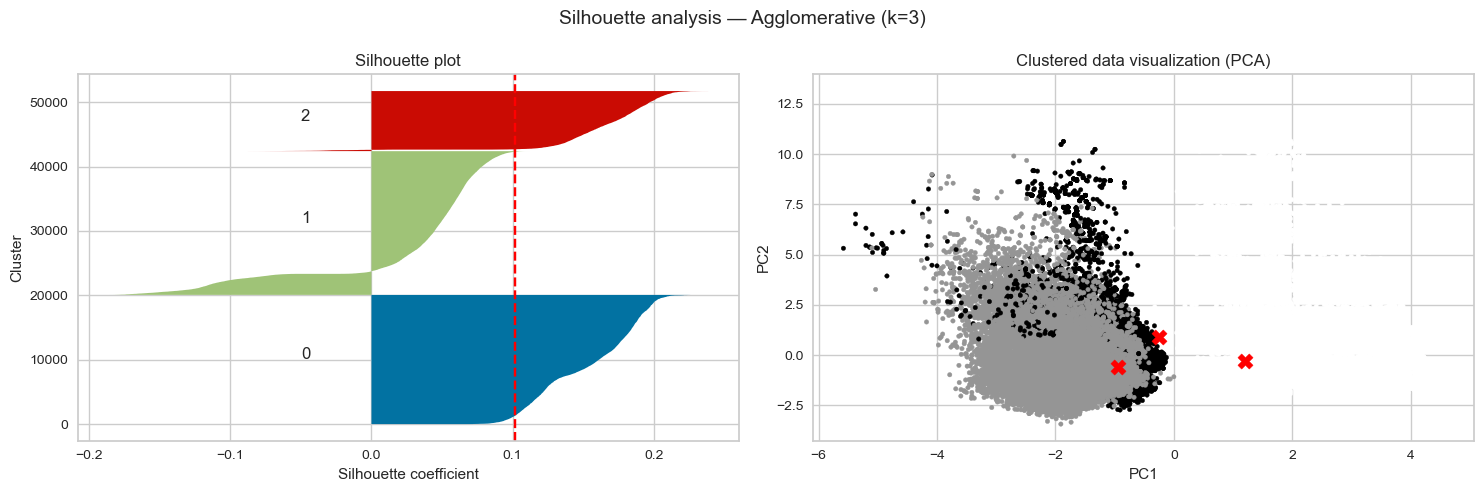


Silhouette promedio para k=4: 0.0878


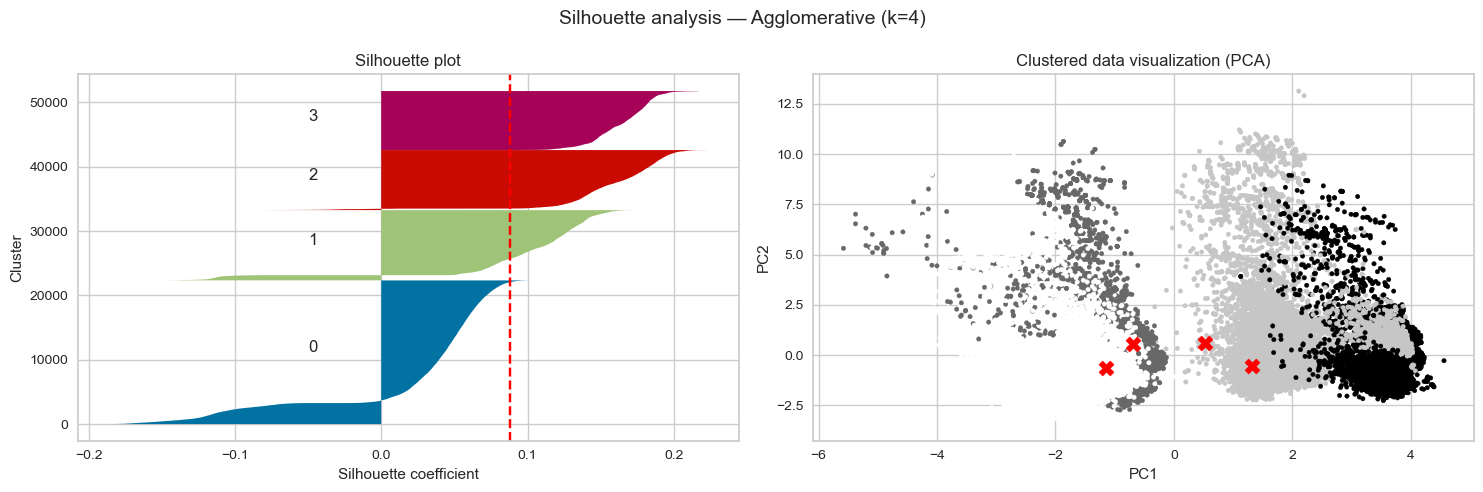


Silhouette promedio para k=5: 0.0961


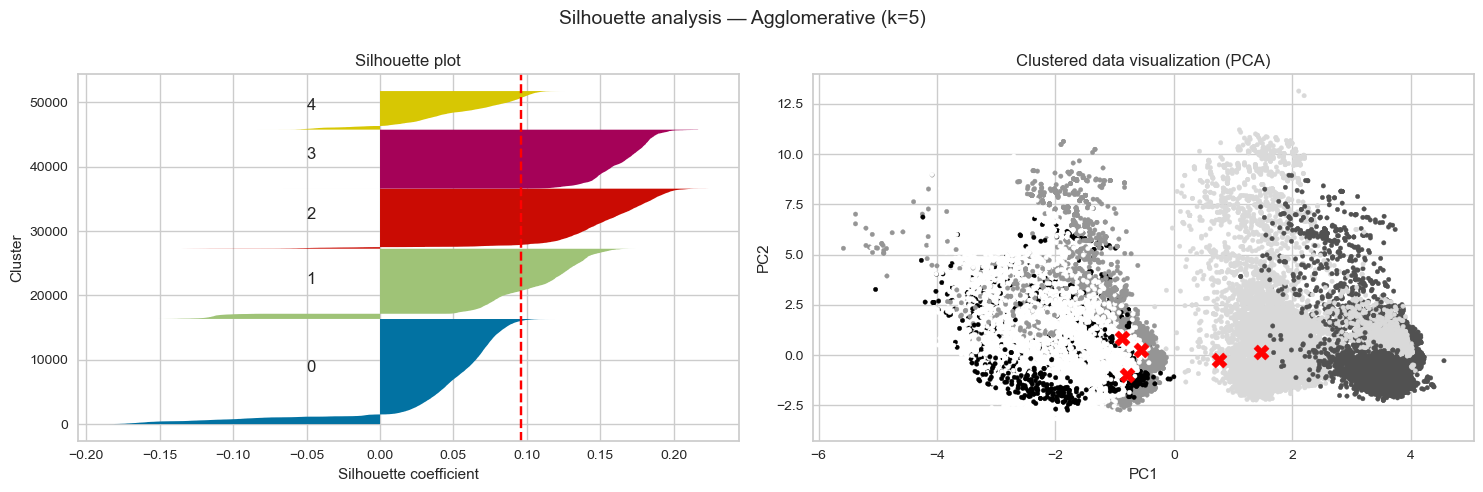

In [29]:
for k_hier in [3, 4, 5]:
    # Entrenar modelo jerárquico
    agglo = AgglomerativeClustering(n_clusters=k_hier, linkage='ward')
    labels_agglo = agglo.fit_predict(df_clustering_final)

    # Métricas Silhouette
    silhouette_avg = silhouette_score(df_clustering_final, labels_agglo)
    sample_silhouette_values = silhouette_samples(df_clustering_final, labels_agglo)
    print(f"\nSilhouette promedio para k={k_hier}: {silhouette_avg:.4f}")

    # Calcular centroides como media de puntos por cluster
    centroides_agglo = np.array([df_clustering_final.values[labels_agglo == i].mean(axis=0)
                                 for i in range(k_hier)])

    # PCA para visualización
    X_pca_2d = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(df_clustering_final))

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f"Silhouette analysis — Agglomerative (k={k_hier})", fontsize=14)

    # ===== SILHOUETTE PLOT =====
    y_lower = 10
    for i in range(k_hier):
        ith_cluster_values = sample_silhouette_values[labels_agglo == i]
        ith_cluster_values.sort()
        size_cluster = ith_cluster_values.shape[0]
        y_upper = y_lower + size_cluster
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_values)
        ax1.text(-0.05, y_lower + size_cluster / 2, str(i))
        y_lower = y_upper + 10

    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_xlabel("Silhouette coefficient")
    ax1.set_ylabel("Cluster")
    ax1.set_title("Silhouette plot")

    # ===== SCATTER (PCA) =====
    ax2.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=labels_agglo, s=10)
    centers_pca = PCA(n_components=2).fit_transform(centroides_agglo)
    ax2.scatter(centers_pca[:, 0], centers_pca[:, 1], c="red", s=120, marker="X")
    ax2.set_title("Clustered data visualization (PCA)")
    ax2.set_xlabel("PC1")
    ax2.set_ylabel("PC2")

    plt.tight_layout()
    plt.show()


### 2.5º RESÚMEN Final Metricas + Distancias --> JERARQUICO

In [30]:
# Datos numéricos
X_numeric = df_clustering_final.values

# ks a evaluar
k_values_hier = [3, 4, 5]

filas = []
resultados_hier = {}

for k in k_values_hier:
    # Modelo jerárquico
    agglo = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels_agglo = agglo.fit_predict(X_numeric)

    # Métricas internas
    sil, db, ch = evaluar_clustering(X_numeric, labels_agglo)

    # Distancias
    dist_intra = calcular_intra_cluster(X_numeric, labels_agglo)
    dist_inter = calcular_inter_cluster(X_numeric, labels_agglo)

    # Centroides (media por cluster)
    centroides = np.array([
        X_numeric[labels_agglo == i].mean(axis=0)
        for i in range(k)
    ])

    # Guardar resultados completos
    resultados_hier[k] = {
        "labels": labels_agglo,
        "silhouette": sil,
        "davies_bouldin": db,
        "calinski_harabasz": ch,
        "centroides": centroides
    }

    filas.append({
        "k": k,
        "Silhouette": round(sil, 4),
        "Davies-Bouldin": round(db, 4),
        "Calinski-Harabasz": round(ch, 4),
        "Distancia_intra_promedio": round(dist_intra, 4),
        "Distancia_min_inter": round(dist_inter, 4)
    })

# Tabla comparativa final
tabla_comparativa_hier = pd.DataFrame(filas).sort_values("k").reset_index(drop=True)

print("\n=== Comparación de métricas y distancias — Clustering Jerárquico ===")
display(tabla_comparativa_hier)



=== Comparación de métricas y distancias — Clustering Jerárquico ===


,k,Silhouette,Davies-Bouldin,Calinski-Harabasz,Distancia_intra_promedio,Distancia_min_inter
0,3,0.1018,2.9237,4587.4789,3.4988,1.6678
1,4,0.0878,2.8269,4025.5214,3.3448,1.6678
2,5,0.0961,2.8339,3643.9898,3.3666,1.6569


### 2.6º Elegir mejor valor de K para JERARQUICO

In [31]:
# Score combinado
tabla_comparativa_hier["score"] = (
    (tabla_comparativa_hier["Silhouette"] / tabla_comparativa_hier["Silhouette"].max()) -
    (tabla_comparativa_hier["Distancia_intra_promedio"] / tabla_comparativa_hier["Distancia_intra_promedio"].max()) +
    (tabla_comparativa_hier["Distancia_min_inter"] / tabla_comparativa_hier["Distancia_min_inter"].max())
)

# Mejor k
k_mejor_hier = int(tabla_comparativa_hier.loc[
    tabla_comparativa_hier["score"].idxmax(), "k"
])

print(f" Mejor k jerárquico según métricas y distancias: {k_mejor_hier}")


 Mejor k jerárquico según métricas y distancias: 3


### --> MODELO JERARQUICO SELECCINADO : k=?

In [32]:
# Extraer fila del mejor k jerárquico
tabla_mejor_k_hier = tabla_comparativa_hier[
    tabla_comparativa_hier["k"] == k_mejor_hier
].reset_index(drop=True)

print(f"\n=== Métricas y distancias del mejor k jerárquico (k = {k_mejor_hier}) ===")
display(tabla_mejor_k_hier)



=== Métricas y distancias del mejor k jerárquico (k = 3) ===


,k,Silhouette,Davies-Bouldin,Calinski-Harabasz,Distancia_intra_promedio,Distancia_min_inter,score
0,3,0.1018,2.9237,4587.4789,3.4988,1.6678,1.0


# -------------------------------------------------------------------------------------------

## 3º Modelo: BDSCAN

### 3.1º Crear Modelo

In [33]:
# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=3)
labels_dbscan = dbscan.fit_predict(df_clustering_final)

# Para silueta, debe haber >1 cluster
if len(set(labels_dbscan)) > 1:
    sil_dbscan = silhouette_score(df_clustering_final, labels_dbscan)
else:
    sil_dbscan = -1
print(f"Silhouette DBSCAN: {sil_dbscan:.4f}")
sil_db, db_db, ch_db = evaluar_clustering(df_clustering_final, labels_dbscan)



Silhouette DBSCAN: -0.1306


### 3.2º Métricas de Validación Interna

In [34]:
# Crear DataFrame con métricas para eps=0.5
tabla_metricas_dbscan = pd.DataFrame({
    "Métrica": ["Silhouette", "Davies-Bouldin", "Calinski-Harabasz"],
    "Valor": [round(sil_dbscan,4), round(db_db,4), round(ch_db,4)]
})

print("\nMétricas de validación interna DBSCAN (eps=0.5):")
display(tabla_metricas_dbscan)



Métricas de validación interna DBSCAN (eps=0.5):


,Métrica,Valor
0,Silhouette,-0.1306
1,Davies-Bouldin,1.0613
2,Calinski-Harabasz,5.8997


### 3.3º Distancia Intra-Cluster e Inter-Cluster + Centroides

In [35]:
# Calcular distancias
intra = calcular_intra_cluster(df_clustering_final.values, labels_dbscan)
inter = calcular_inter_cluster(df_clustering_final.values, labels_dbscan)

# Tabla de distancias
tabla_distancias = pd.DataFrame({
    "Tipo de distancia": ["Intra-cluster", "Inter-cluster"],
    "Valor promedio": [round(intra,4), round(inter,4)]
})

print("\nDistancias promedio DBSCAN (eps=0.5):")
display(tabla_distancias)

# Centroides
centroides_dbscan = obtener_centroides(df_clustering_final.values, labels_dbscan)
print("\nCentroides por cluster (ignorando ruido):")
display(pd.DataFrame(centroides_dbscan))



Distancias promedio DBSCAN (eps=0.5):


,Tipo de distancia,Valor promedio
0,Intra-cluster,0.0963
1,Inter-cluster,1.0000



Centroides por cluster (ignorando ruido):


,0,1,2,3,4,5,6,7,8,9,...,76,77,78,79,80,81,82,83,84,85
0,0.007726,0.025316,0.1,0.0,0.0,0.0,0.0,0.040195,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.007726,0.021097,0.1,0.0,0.0,0.0,0.0,0.032022,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.012877,0.021097,0.266667,0.083333,0.0,0.0,0.0,0.087909,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.14128,0.037975,0.2,0.0,0.0,0.0,0.0,0.184889,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.007726,0.015823,0.3,0.0625,0.0,0.0,0.0,0.082561,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3115,0.062546,0.021097,0.166667,0.0,0.0,0.0,0.0,0.299294,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3116,0.007726,0.012658,0.2,0.0,0.0,0.0,1.0,0.078502,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3117,0.051508,0.050633,0.3,0.125,0.0,0.0,0.0,0.467019,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3118,0.032377,0.037975,0.1,0.125,1.0,0.04058,0.0,0.29195,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


### 3.4º Visuaización Silhoutte + PCA

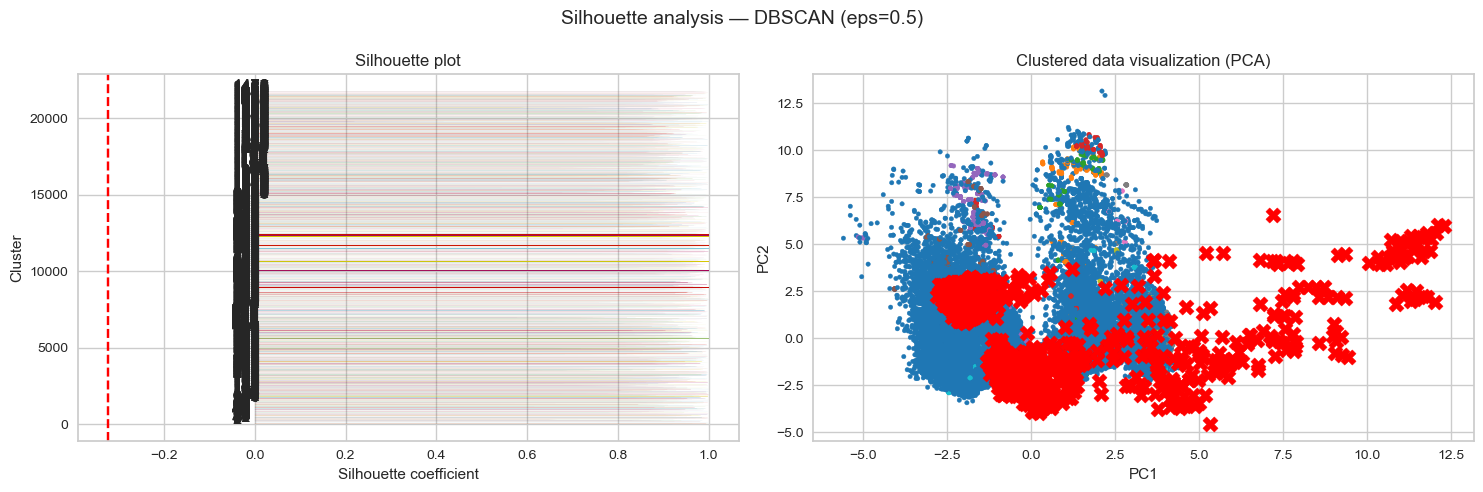

In [36]:

# Escalar datos solo para PCA
X_scaled = StandardScaler().fit_transform(df_clustering_final.values)

# Modelo DBSCAN con eps=0.5
dbscan = DBSCAN(eps=0.5, min_samples=3)
labels_dbscan = dbscan.fit_predict(X_scaled)

# Silhouette
if len(set(labels_dbscan)) > 1:
    sil_avg = silhouette_score(X_scaled, labels_dbscan)
    sample_sil_values = silhouette_samples(X_scaled, labels_dbscan)
else:
    sil_avg = -1
    sample_sil_values = None

# Centroides
centroides_dbscan = obtener_centroides(X_scaled, labels_dbscan)

# PCA
X_pca_2d = PCA(n_components=2).fit_transform(X_scaled)

if sil_avg > -1:
    fig, (ax1, ax2) = plt.subplots(1,2,figsize=(15,5))
    fig.suptitle(f"Silhouette analysis — DBSCAN (eps=0.5)", fontsize=14)

    # Silhouette plot
    y_lower = 10
    n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
    for i in range(n_clusters):
        ith_values = sample_sil_values[labels_dbscan == i]
        ith_values.sort()
        size_cluster = ith_values.shape[0]
        y_upper = y_lower + size_cluster
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_values)
        ax1.text(-0.05, y_lower + size_cluster/2, str(i))
        y_lower = y_upper + 10

    ax1.axvline(x=sil_avg, color="red", linestyle="--")
    ax1.set_xlabel("Silhouette coefficient")
    ax1.set_ylabel("Cluster")
    ax1.set_title("Silhouette plot")

    # Scatter PCA
    ax2.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=labels_dbscan, s=10, cmap='tab10')
    if len(centroides_dbscan) > 0:
        centers_pca = PCA(n_components=2).fit_transform(centroides_dbscan)
        ax2.scatter(centers_pca[:,0], centers_pca[:,1], c="red", s=120, marker="X")
    ax2.set_title("Clustered data visualization (PCA)")
    ax2.set_xlabel("PC1")
    ax2.set_ylabel("PC2")

    plt.tight_layout()
    plt.show()


# -------------------------------------------------------------------------------------------

# TABLA COMPARATIVA 3 MODELOS

In [37]:
# FUNCIÓN  PARA DISTRIBUCIÓN (Para que la distribucion salga en tipo lista)
def distribucion_clusters_lista(labels):
    return (
        pd.Series(labels)
        .value_counts()
        .sort_index()
        .astype(int)
        .tolist()
    )


# DATOS
X = df_clustering_final.values
filas = []


# K-MEANS 
labels_kmeans = resultados_clusters[k_mejor]["etiquetas"]

filas.append({
    "Modelo": "K-Means",
    "Valor_K": int(k_mejor),
    "Distribucion_clusters": distribucion_clusters_lista(labels_kmeans),
    "Silhouette": round(float(tabla_mejor_k_KMEANS.loc[0, "Silhouette"]), 4),
    "Davies-Bouldin": round(float(tabla_mejor_k_KMEANS.loc[0, "Davies-Bouldin"]), 4),
    "Calinski-Harabasz": round(float(tabla_mejor_k_KMEANS.loc[0, "Calinski-Harabasz"]), 4),
    "Distancia_intra": round(float(tabla_mejor_k_KMEANS.loc[0, "Distancia_intra_promedio"]), 4),
    "Distancia_inter": round(float(tabla_mejor_k_KMEANS.loc[0, "Distancia_min_inter"]), 4)
})


# JERÁRQUICO
labels_hier = resultados_hier[k_mejor_hier]["labels"]

filas.append({
    "Modelo": "Jerárquico (Ward)",
    "Valor_K": int(k_mejor_hier),
    "Distribucion_clusters": distribucion_clusters_lista(labels_hier),
    "Silhouette": round(float(tabla_mejor_k_hier.loc[0, "Silhouette"]), 4),
    "Davies-Bouldin": round(float(tabla_mejor_k_hier.loc[0, "Davies-Bouldin"]), 4),
    "Calinski-Harabasz": round(float(tabla_mejor_k_hier.loc[0, "Calinski-Harabasz"]), 4),
    "Distancia_intra": round(float(tabla_mejor_k_hier.loc[0, "Distancia_intra_promedio"]), 4),
    "Distancia_inter": round(float(tabla_mejor_k_hier.loc[0, "Distancia_min_inter"]), 4)
})


# DBSCAN 
sil_db, db_db, ch_db = evaluar_clustering(X, labels_dbscan)
dist_intra_db = calcular_intra_cluster(X, labels_dbscan)
dist_inter_db = calcular_inter_cluster(X, labels_dbscan)

filas.append({
    "Modelo": "DBSCAN",
    "Valor_K": np.nan,
    "Distribucion_clusters": distribucion_clusters_lista(labels_dbscan),
    "Silhouette": round(float(sil_db), 4),
    "Davies-Bouldin": round(float(db_db), 4),
    "Calinski-Harabasz": round(float(ch_db), 4),
    "Distancia_intra": round(float(dist_intra_db), 4),
    "Distancia_inter": round(float(dist_inter_db), 4)
})



# TABLA FINAL
tabla_final_modelos = pd.DataFrame(filas)

print("=== TABLA FINAL DE MODELOS ===")
display(tabla_final_modelos)


=== TABLA FINAL DE MODELOS ===


,Modelo,Valor_K,Distribucion_clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz,Distancia_intra,Distancia_inter
0,K-Means,3.0,"[20060, 19287, 12360]",0.1273,2.6230,5436.8672,3.4920,1.9062
1,Jerárquico (Ward),3.0,"[20060, 22320, 9327]",0.1018,2.9237,4587.4789,3.4988,1.6678
2,DBSCAN,NaN,"[44667, 3, 4, 6, 3, 4, 3, 3, 4, 5, 5, 3, 3, 4,...",-0.3069,1.0381,5.0024,0.0116,0.0295


### AÑADIR CLUSTER K-MEANS AL DATAFRAME ORIGINAL (df)

In [38]:
# AÑADIR CLUSTER K-MEANS (k=3) AL DF ORIGINAL
 
# Etiquetas del mejor modelo K-Means
labels_kmeans_final = resultados_clusters[k_mejor]["etiquetas"]

# Añadir columna de cluster
df["cluster_kmeans_3"] = labels_kmeans_final

df[["cluster_kmeans_3"]].head()


,cluster_kmeans_3
0,0
1,0
2,0
3,0
4,0


### AÑADIR CLUSTERS EN FORMATO DUMMIES A df_clustering_final

In [39]:
# CLUSTERS K-MEANS COMO DUMMIES

# Crear DataFrame auxiliar con etiquetas
df_clusters = pd.DataFrame({
    "cluster_kmeans_3": labels_kmeans_final
}, index=df_clustering_final.index)

# Convertir a dummies
df_clusters_dummies = pd.get_dummies(
    df_clusters["cluster_kmeans_3"],
    prefix="cluster",
    drop_first=False
)

# Unir al df_clustering_final
df_clustering_final_con_clusters = pd.concat(
    [df_clustering_final, df_clusters_dummies],
    axis=1
)

df_clustering_final_con_clusters.head()


,lead_time,lenght_of_stay,adult_count,child_count,returning_inhabitant,recurrence,libere_community,reservation_net_value,zona_roja_mes,estancia_en_festivo,...,City_Vitoria,Reserva_Dia_Semana_Monday,Reserva_Dia_Semana_Saturday,Reserva_Dia_Semana_Sunday,Reserva_Dia_Semana_Thursday,Reserva_Dia_Semana_Tuesday,Reserva_Dia_Semana_Wednesday,cluster_0,cluster_1,cluster_2
0,0.047461,0.012658,0.1,0.00,1.0,0.026087,0.0,0.015921,0.0,0.0,...,False,False,True,False,False,False,False,True,False,False
1,0.019868,0.113924,0.1,0.00,1.0,0.008696,1.0,0.117788,0.0,1.0,...,False,False,False,False,False,False,True,True,False,False
2,0.120309,0.075949,0.2,0.50,0.0,0.000000,0.0,0.755703,0.0,1.0,...,False,False,False,False,False,False,True,True,False,False
3,0.116998,0.012658,0.2,0.25,0.0,0.000000,0.0,0.186383,1.0,0.0,...,False,False,True,False,False,False,False,True,False,False
4,0.090508,0.012658,0.4,0.00,0.0,0.000000,0.0,0.077025,1.0,0.0,...,False,False,False,False,False,True,False,True,False,False


### Guardar csv-s

In [41]:
# GUARDAR DF ORIGINAL CON CLUSTERS
df_limpio_con_clusters = df.copy()  # df ya tiene la columna cluster_kmeans_3
df_limpio_con_clusters.to_csv("df_limpio_con_clusters.csv", index=False)

# GUARDAR DF DE MODELADO CON CLUSTERS DUMMIES
df_modelado_clustering = df_clustering_final_con_clusters.copy()
df_modelado_clustering.to_csv("df_modelado_clustering.csv", index=False)
